In [2]:
#Load ios feature selected dataset for modeling:
import pandas as pd
ios_selected_features = pd.read_csv("../Processed_Data/Selected_FeaturesDatasets/ios_SelectedFeatures.csv")

**Train/Test Split**

In [3]:
#Preparing dataset for training:
#Select relevant columns for analysis:
y = ios_selected_features['stress']
X = ios_selected_features.drop(columns=['stress', 'uid', 'day'])  # Drop target, ID columns, and date
print("Final feature set columns:", X.columns)
print("Final feature set shape:", X.shape)  

Final feature set columns: Index(['Unnamed: 0.1', 'act_still_ep_0', 'race_more than one', 'Unnamed: 0',
       'audio_voice_ep_3', 'race_american indian/white', 'loc_self_dorm_still',
       'social_level', 'sleep_end', 'pam', 'loc_max_dis_from_campus_ep_0',
       'loc_study_convo_num', 'loc_study_unlock_duration', 'phq4_score',
       'unlock_num_ep_0', 'loc_self_dorm_audio_voice', 'act_walking_ep_0',
       'sse3-4', 'loc_study_dur', 'sse3-3',
       'race_american indian/alaska native', 'sse3_resp_mean', 'phq4-2',
       'gender', 'phq4-4', 'act_in_vehicle_ep_0', 'loc_self_dorm_dur',
       'race_alaskan native/white', 'race_white', 'avg_ema_spent_time',
       'act_still_ep_2', 'phq4-1', 'act_in_vehicle_ep_2', 'sleep_duration',
       'audio_convo_num_ep_3', 'quality_audio', 'loc_study_audio_voice',
       'quality_loc', 'loc_self_dorm_unlock_num', 'sse3-1',
       'loc_self_dorm_unlock_duration', 'sse3_resp_median', 'loc_study_still',
       'race_black', 'race_other/hispanic', '

In [4]:
#checking for missing values:
print("Missing values in each column:")
print(X.isnull().sum())

Missing values in each column:
Unnamed: 0.1                              0
act_still_ep_0                            0
race_more than one                        0
Unnamed: 0                                0
audio_voice_ep_3                          0
race_american indian/white                0
loc_self_dorm_still                   18650
social_level                              0
sleep_end                                 0
pam                                     374
loc_max_dis_from_campus_ep_0           5331
loc_study_convo_num                   19673
loc_study_unlock_duration             19673
phq4_score                                0
unlock_num_ep_0                           0
loc_self_dorm_audio_voice             18650
act_walking_ep_0                          0
sse3-4                                    0
loc_study_dur                            27
sse3-3                                    0
race_american indian/alaska native        0
sse3_resp_mean                            0
p

In [5]:
#Splitting data into test and train sets to prevent data leakage:
from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold

#Column that identifies groups (participants):
group_col = 'uid'

#80/20 training testing split, with one testing group:
gss = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=ios_selected_features[group_col]))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
groups_train = ios_selected_features[group_col].iloc[train_idx]

#Checking stress label distribution to ensure the groups are stratified:
print("Train distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest distribution:")
print(y_test.value_counts(normalize=True))

Train distribution:
stress
2.0    0.335620
3.0    0.292450
1.0    0.173687
4.0    0.144979
5.0    0.053264
Name: proportion, dtype: float64

Test distribution:
stress
2.0    0.359751
3.0    0.285915
1.0    0.171950
4.0    0.142055
5.0    0.040329
Name: proportion, dtype: float64


In [6]:
import numpy as np
y_pred_baseline = np.full_like(y_test, y_train.mean())

# 3. Evaluate baseline
from sklearn.metrics import mean_squared_error
baseline_mse = mean_squared_error(y_test, y_pred_baseline)

print("Baseline MSE:", baseline_mse)

Baseline MSE: 1.122066177499269


In [7]:
#Stratified group k-fold cross-validation to evaluate model performance:
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
for fold, (train_idx, val_idx) in enumerate(sgkf.split(X_train, y_train, groups=groups_train)):
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

**Random Forest Regressor - Global**

In [8]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

rf_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt', 
    random_state=42,
    n_jobs=-1
)

RF_fold_rmse = []
RF_fold_mae = []
RF_fold_r2 = []

for fold, (train_idx, val_idx) in enumerate(sgkf.split(X_train, y_train, groups=groups_train)):
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    rf_model.fit(X_fold_train, y_fold_train)
    val_preds = rf_model.predict(X_fold_val)
    
    rmse = np.sqrt(mean_squared_error(y_fold_val, val_preds))
    mae = mean_absolute_error(y_fold_val, val_preds)
    r2 = r2_score(y_fold_val, val_preds)
    
    RF_fold_rmse.append(rmse)
    RF_fold_mae.append(mae)
    RF_fold_r2.append(r2)
    
    print(f"Fold {fold+1} - RMSE: {rmse:.4f}, MAE: {mae:.4f}, R^2: {r2:.4f}")

print(f"\nAverage RMSE across folds: {np.mean(RF_fold_rmse):.4f}")
print(f"Average MAE across folds: {np.mean(RF_fold_mae):.4f}")
print(f"Average R^2 across folds: {np.mean(RF_fold_r2):.4f}")

Fold 1 - RMSE: 0.8401, MAE: 0.6777, R^2: 0.4169
Fold 2 - RMSE: 0.8256, MAE: 0.6672, R^2: 0.4295
Fold 3 - RMSE: 0.8857, MAE: 0.7023, R^2: 0.3482
Fold 4 - RMSE: 0.8711, MAE: 0.6833, R^2: 0.3699
Fold 5 - RMSE: 0.8466, MAE: 0.6896, R^2: 0.4016

Average RMSE across folds: 0.8538
Average MAE across folds: 0.6841
Average R^2 across folds: 0.3932


In [9]:
#Final evaluation on the test set:
rf_model.fit(X_train, y_train)
test_preds = rf_model.predict(X_test)
test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))
test_mae = mean_absolute_error(y_test, test_preds)                       
test_r2 = r2_score(y_test, test_preds)
print(f"\nTest Set - RMSE: {test_rmse:.4f}, MAE: {test_mae:.4f}, R^2: {test_r2:.4f}")


Test Set - RMSE: 0.8484, MAE: 0.6762, R^2: 0.3571


In [10]:
#Functions to convert regression predictions to class labels and compute accuracy:
from sklearn.metrics import accuracy_score
import numpy as np

# Define function to convert regression predictions to class labels based on binning:
def regression_to_class(y_pred):
    # Define bin edges
    bins = [1.5, 2.5, 3.5, 4.5]
    
    # Convert to class labels 1–5
    y_class = np.digitize(y_pred, bins) + 1
    
    return y_class

# Define function to compute per-class accuracy:
def per_class_accuracy(y_true, y_pred_class):
    classes = [1, 2, 3, 4, 5]
    class_acc = {}

    for c in classes:
        idx = (y_true == c)
        
        if np.sum(idx) == 0:
            class_acc[c] = None  # or "N/A"
        else:
            class_acc[c] = np.mean(y_pred_class[idx] == c)

    return class_acc

In [11]:
#Computing accuracy for by converting regression predictions to class labels:
# Regression predictions
y_pred_reg = rf_model.predict(X_test)

# Convert to classes
y_pred_reg = np.clip(y_pred_reg, 1, 5)
y_pred_class = regression_to_class(y_pred_reg)
y_test_int = y_test.astype(int)

# Accuracy
acc = accuracy_score(y_test_int, y_pred_class)

# Compute per-class accuracy
class_acc = per_class_accuracy(y_test_int, y_pred_class)

print(f"Regression → Classification Accuracy: {acc:.2f}")
print("\nPer-class accuracy:")
for c, acc in class_acc.items():
    if acc is None:
        print(f"Class {c}: N/A")
    else:
        print(f"Class {c}: {acc:.3f}")


Regression → Classification Accuracy: 0.44

Per-class accuracy:
Class 1: 0.086
Class 2: 0.632
Class 3: 0.622
Class 4: 0.106
Class 5: 0.010


**LightGBM Regressor - Global**

In [12]:
#lightGBM regression model cannot handle special characters in column names, so we need to clean the feature names before training:
import re

X_train = X_train.copy()

X_train.columns = [
    re.sub(r'[^A-Za-z0-9_]+', '_', col)
    for col in X_train.columns]

X_test = X_test.copy()
X_test.columns = [
    re.sub(r'[^A-Za-z0-9_]+', '_', col)
    for col in X_test.columns]

In [13]:
# LightGBM regression model with stratified group k-fold cross-validation:

from lightgbm import LGBMRegressor

lgbm_model = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.02,
    max_depth=10,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    force_row_wise=True,
    random_state=42,
    n_jobs=-1
)

LGBM_fold_rmse = []
LGBM_fold_mae = []
LGBM_fold_r2 = []

for fold, (train_idx, val_idx) in enumerate(sgkf.split(X_train, y_train, groups=groups_train)):
    
    X_fold_train = X_train.iloc[train_idx]
    X_fold_val = X_train.iloc[val_idx]
    y_fold_train = y_train.iloc[train_idx]
    y_fold_val = y_train.iloc[val_idx]
    
    lgbm_model.fit(X_fold_train, y_fold_train)
    
    val_preds = lgbm_model.predict(X_fold_val)
    
    rmse = np.sqrt(mean_squared_error(y_fold_val, val_preds))
    mae = mean_absolute_error(y_fold_val, val_preds)
    r2 = r2_score(y_fold_val, val_preds)
    
    LGBM_fold_rmse.append(rmse)
    LGBM_fold_mae.append(mae)
    LGBM_fold_r2.append(r2)
    
    print(f"Fold {fold+1} - RMSE: {rmse:.4f}, MAE: {mae:.4f}, R^2: {r2:.4f}")

print(f"\nAverage RMSE across folds: {np.mean(LGBM_fold_rmse):.4f}")
print(f"Average MAE across folds: {np.mean(LGBM_fold_mae):.4f}")
print(f"Average R^2 across folds: {np.mean(LGBM_fold_r2):.4f}")

[LightGBM] [Info] Total Bins 6381
[LightGBM] [Info] Number of data points in the train set: 18304, number of used features: 45
[LightGBM] [Info] Start training from score 2.567035
Fold 1 - RMSE: 0.8344, MAE: 0.6651, R^2: 0.4249
[LightGBM] [Info] Total Bins 6366
[LightGBM] [Info] Number of data points in the train set: 18340, number of used features: 45
[LightGBM] [Info] Start training from score 2.571210
Fold 2 - RMSE: 0.8151, MAE: 0.6464, R^2: 0.4439
[LightGBM] [Info] Total Bins 6380
[LightGBM] [Info] Number of data points in the train set: 18283, number of used features: 45
[LightGBM] [Info] Start training from score 2.567084
Fold 3 - RMSE: 0.8687, MAE: 0.6812, R^2: 0.3729
[LightGBM] [Info] Total Bins 6368
[LightGBM] [Info] Number of data points in the train set: 18296, number of used features: 45
[LightGBM] [Info] Start training from score 2.567720
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Fold 4 - RMSE: 0.8679, MAE: 0.6733, R^2: 0.3745
[LightGBM] [I

In [14]:
#Final evaluation on the test set:
lgbm_model.fit(X_train, y_train)
test_preds = lgbm_model.predict(X_test)
test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))
test_mae = mean_absolute_error(y_test, test_preds)                       
test_r2 = r2_score(y_test, test_preds)
print(f"\nTest Set - RMSE: {test_rmse:.4f}, MAE: {test_mae:.4f}, R^2: {test_r2:.4f}")

[LightGBM] [Info] Total Bins 6390
[LightGBM] [Info] Number of data points in the train set: 22886, number of used features: 45
[LightGBM] [Info] Start training from score 2.568514

Test Set - RMSE: 0.8195, MAE: 0.6492, R^2: 0.4002


In [15]:
#Computing accuracy for by converting regression predictions to class labels:
# Regression predictions
y_pred_reg = lgbm_model.predict(X_test)

# Convert to classes
y_pred_reg = np.clip(y_pred_reg, 1, 5)
y_pred_class = regression_to_class(y_pred_reg)
y_test_int = y_test.astype(int)

# Accuracy
acc = accuracy_score(y_test_int, y_pred_class)

# Compute per-class accuracy
class_acc = per_class_accuracy(y_test_int, y_pred_class)

print(f"Regression → Classification Accuracy: {acc:.2f}")
print("\nPer-class accuracy:")
for c, acc in class_acc.items():
    if acc is None:
        print(f"Class {c}: N/A")
    else:
        print(f"Class {c}: {acc:.3f}")


Regression → Classification Accuracy: 0.46

Per-class accuracy:
Class 1: 0.202
Class 2: 0.634
Class 3: 0.589
Class 4: 0.178
Class 5: 0.060


**XGBoost Regressor - Global**

In [16]:
#XGBoost regression model with stratifed group k-fold cross-validation:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=500,
    max_depth=10,
    learning_rate=0.01,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    random_state=42,
    n_jobs=-1
)

XGB_fold_rmse = []
XGB_fold_mae = []
XGB_fold_r2 = []

for fold, (train_idx, val_idx) in enumerate(sgkf.split(X_train, y_train, groups=groups_train)):
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    xgb_model.fit(X_fold_train, y_fold_train)
    val_preds = xgb_model.predict(X_fold_val)
    
    rmse = np.sqrt(mean_squared_error(y_fold_val, val_preds))
    mae = mean_absolute_error(y_fold_val, val_preds)
    r2 = r2_score(y_fold_val, val_preds)
    
    XGB_fold_rmse.append(rmse)
    XGB_fold_mae.append(mae)
    XGB_fold_r2.append(r2)
    
    print(f"Fold {fold+1} - RMSE: {rmse:.4f}, MAE: {mae:.4f}, R^2: {r2:.4f}")

print(f"\nAverage RMSE across folds: {np.mean(XGB_fold_rmse):.4f}")
print(f"Average MAE across folds: {np.mean(XGB_fold_mae):.4f}")
print(f"Average R^2 across folds: {np.mean(XGB_fold_r2):.4f}")

Fold 1 - RMSE: 0.8295, MAE: 0.6610, R^2: 0.4315
Fold 2 - RMSE: 0.8114, MAE: 0.6479, R^2: 0.4489
Fold 3 - RMSE: 0.8768, MAE: 0.6911, R^2: 0.3612
Fold 4 - RMSE: 0.8789, MAE: 0.6830, R^2: 0.3586
Fold 5 - RMSE: 0.8316, MAE: 0.6731, R^2: 0.4227

Average RMSE across folds: 0.8456
Average MAE across folds: 0.6712
Average R^2 across folds: 0.4046


In [17]:
#Final evaluation on the test set:
xgb_model.fit(X_train, y_train)
test_preds = xgb_model.predict(X_test)
test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))
test_mae = mean_absolute_error(y_test, test_preds)                       
test_r2 = r2_score(y_test, test_preds)
print(f"\nTest Set - RMSE: {test_rmse:.4f}, MAE: {test_mae:.4f}, R^2: {test_r2:.4f}")


Test Set - RMSE: 0.8258, MAE: 0.6564, R^2: 0.3909


In [18]:
#Computing accuracy for by converting regression predictions to class labels:
# Regression predictions
y_pred_reg = xgb_model.predict(X_test)

# Convert to classes
y_pred_reg = np.clip(y_pred_reg, 1, 5)
y_pred_class = regression_to_class(y_pred_reg)
y_test_int = y_test.astype(int)

# Accuracy
acc = accuracy_score(y_test_int, y_pred_class)

# Compute per-class accuracy
class_acc = per_class_accuracy(y_test_int, y_pred_class)

print(f"Regression → Classification Accuracy: {acc:.2f}")
print("\nPer-class accuracy:")
for c, acc in class_acc.items():
    if acc is None:
        print(f"Class {c}: N/A")
    else:
        print(f"Class {c}: {acc:.3f}")


Regression → Classification Accuracy: 0.46

Per-class accuracy:
Class 1: 0.197
Class 2: 0.636
Class 3: 0.604
Class 4: 0.179
Class 5: 0.045


**XGBoost Regressor - Personalized**

In [19]:
from sklearn.model_selection import train_test_split

# Training personalized models for each participant:
unique_participants = ios_selected_features['uid'].unique()

P_XGB_models = {}
P_XGB_train_metrics = {}

for participant in unique_participants:
    
    participant_data = ios_selected_features[
        ios_selected_features['uid'] == participant
    ].sort_values('day')  # keep time order

    # Removing race to evaluate fairness of model
    race_cols = [col for col in participant_data.columns if col.startswith('race_')]
    race_labels = participant_data[race_cols].idxmax(axis=1) 
    race_labels = race_labels.str.replace('race_', '')
    
    #Extract gender for fairness evaluation
    gender = participant_data['gender']

    X = participant_data.drop(columns=['stress', 'uid', 'day'] + race_cols)  
    y = participant_data['stress']
    
    y = y.replace(5, 4)
    
    # Skip participants with too few data points
    if len(participant_data) < 15:
        continue
    
    # Time based split: 60% train, 20% val, 20% test
    split1 = int(len(X) * 0.6)
    split2 = int(len(X) * 0.8)

    X_train = X.iloc[:split1]
    y_train = y.iloc[:split1]

    X_val = X.iloc[split1:split2]
    y_val = y.iloc[split1:split2]

    X_test = X.iloc[split2:]
    y_test = y.iloc[split2:]
    
    #align gender with test set
    gender_test = gender.iloc[split2:]

    # Model
    P_XGB_model = XGBRegressor(
        n_estimators=400,
        max_depth=5,
        learning_rate=0.01,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=3,
        alpha=1,
        random_state=42,
        n_jobs=-1
    )
    
    # Train
    P_XGB_model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False,
    )
    
    train_preds = P_XGB_model.predict(X_train)
    val_preds = P_XGB_model.predict(X_val)
    
    # Metrics:
    train_rmse = np.sqrt(mean_squared_error(y_train, train_preds))
    val_rmse = np.sqrt(mean_squared_error(y_val, val_preds))
    
    train_mae = mean_absolute_error(y_train, train_preds)
    val_mae = mean_absolute_error(y_val, val_preds)
    
    P_XGB_train_metrics[participant] = {
        'train_rmse': train_rmse,
        'val_rmse': val_rmse,
        'train_mae': train_mae,
        'val_mae': val_mae
    }
    
    # Store model + test data
    P_XGB_models[participant] = {
        'model': P_XGB_model,
        'X_test': X_test,
        'y_test': y_test,
        'race_test': race_labels.iloc[split2:],
        'gender_test': gender_test  
    }

In [20]:
# Calculate and print average training and validation RMSE + MAE
avg_train_rmse = sum(m['train_rmse'] for m in P_XGB_train_metrics.values()) / len(P_XGB_train_metrics)
avg_val_rmse = sum(m['val_rmse'] for m in P_XGB_train_metrics.values()) / len(P_XGB_train_metrics)

avg_train_mae = sum(m['train_mae'] for m in P_XGB_train_metrics.values()) / len(P_XGB_train_metrics)
avg_val_mae = sum(m['val_mae'] for m in P_XGB_train_metrics.values()) / len(P_XGB_train_metrics)

print(f"Average TRAIN RMSE: {avg_train_rmse:.4f}")
print(f"Average VALIDATION RMSE: {avg_val_rmse:.4f}")

print(f"Average TRAIN MAE: {avg_train_mae:.4f}")
print(f"Average VALIDATION MAE: {avg_val_mae:.4f}")

Average TRAIN RMSE: 0.2677
Average VALIDATION RMSE: 0.7948
Average TRAIN MAE: 0.2051
Average VALIDATION MAE: 0.6574


In [21]:
# Calculate test metrics for each personalized model:
P_XGB_test_metrics = {}

for participant, data in P_XGB_models.items():
    
    P_XGB_model = data['model']
    X_test = data['X_test']
    y_test = data['y_test']
    
    preds = P_XGB_model.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    
    P_XGB_test_metrics[participant] = {
        'test_rmse': rmse,
        'test_mae': mae,
        'test_r2': r2
    }

In [22]:
# Calculate and print average test metrics across all personalized models:
avg_test_rmse = sum(m['test_rmse'] for m in P_XGB_test_metrics.values()) / len(P_XGB_test_metrics)
avg_test_mae = sum(m['test_mae'] for m in P_XGB_test_metrics.values()) / len(P_XGB_test_metrics)
avg_test_r2 = sum(m['test_r2'] for m in P_XGB_test_metrics.values()) / len(P_XGB_test_metrics)

print(f"\nAverage TEST RMSE (FINAL): {avg_test_rmse:.4f}")
print(f"Average TEST MAE (FINAL): {avg_test_mae:.4f}")
print(f"Average TEST R^2 (FINAL): {avg_test_r2:.4f}")


Average TEST RMSE (FINAL): 0.8072
Average TEST MAE (FINAL): 0.6693
Average TEST R^2 (FINAL): -0.4628


In [23]:
#Accuracy of personalized models:
y_pred_reg = P_XGB_model.predict(X_test)

# Convert to classes
y_pred_reg = np.clip(y_pred_reg, 1, 5)
y_pred_class = regression_to_class(y_pred_reg)
y_test_int = y_test.astype(int)

# Accuracy
acc = accuracy_score(y_test_int, y_pred_class)

# Compute per-class accuracy
class_acc = per_class_accuracy(y_test_int, y_pred_class)

print(f"Regression → Classification Accuracy: {acc:.2f}")
print("\nPer-class accuracy:")
for c, acc in class_acc.items():
    if acc is None:
        print(f"Class {c}: N/A")
    else:
        print(f"Class {c}: {acc:.3f}")


Regression → Classification Accuracy: 0.35

Per-class accuracy:
Class 1: 0.000
Class 2: 0.250
Class 3: 0.500
Class 4: 0.000
Class 5: N/A


**LightGBM Regressor - Personalized**

In [24]:
#Personalized LightGBM models for each participant:

P_LGBM_models = {}
P_LGBM_train_metrics = {}

# Loop through each participant
for participant in unique_participants:
    
    participant_data = ios_selected_features[
        ios_selected_features['uid'] == participant
    ].sort_values('day')  # keep time ordering
    
    X = participant_data.drop(columns=['stress', 'uid', 'day'])
    y = participant_data['stress']

    y = y.replace(5, 4)
    
    # Skip small datasets
    if len(participant_data) < 15:
        continue
    
    #Time-based split (60 / 20 / 20)
    split1 = int(len(X) * 0.6)
    split2 = int(len(X) * 0.8)

    X_train = X.iloc[:split1]
    y_train = y.iloc[:split1]

    X_val = X.iloc[split1:split2]
    y_val = y.iloc[split1:split2]

    X_test = X.iloc[split2:]
    y_test = y.iloc[split2:]

    #Removing special characters from column names for LightGBM:
    X_train.columns = [
        re.sub(r'[^A-Za-z0-9_]+', '_', col)
        for col in X_train.columns]
    X_test.columns = [
        re.sub(r'[^A-Za-z0-9_]+', '_', col)
        for col in X_test.columns]
    
    # Random Forest model
    P_lgbm_model = LGBMRegressor(
            n_estimators=300,
            learning_rate=0.01,
            max_depth=5,
            num_leaves=31,
            subsample=0.8,
            colsample_bytree=0.8,
            force_row_wise=True,
            random_state=42,
            n_jobs=-1
        )

    #Train
    P_lgbm_model.fit(X_train, y_train)
    
    #Predictions
    train_preds = P_lgbm_model.predict(X_train)
    val_preds = P_lgbm_model.predict(X_val)
    
    #Metrics
    train_rmse = np.sqrt(mean_squared_error(y_train, train_preds))
    val_rmse = np.sqrt(mean_squared_error(y_val, val_preds))
    
    train_mae = mean_absolute_error(y_train, train_preds)
    val_mae = mean_absolute_error(y_val, val_preds)
    
    P_LGBM_train_metrics[participant] = {
        'train_rmse': train_rmse,
        'val_rmse': val_rmse,
        'train_mae': train_mae,
        'val_mae': val_mae
    }
    
    # Store model + test data
    P_LGBM_models[participant] = {
        'model': P_lgbm_model,
        'X_test': X_test,
        'y_test': y_test
    }

[LightGBM] [Info] Total Bins 796
[LightGBM] [Info] Number of data points in the train set: 120, number of used features: 38
[LightGBM] [Info] Start training from score 2.775000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

In [25]:
# Calculate and print average training and validation RMSE + MAE
avg_train_rmse = sum(m['train_rmse'] for m in P_LGBM_train_metrics.values()) / len(P_LGBM_train_metrics)
avg_val_rmse = sum(m['val_rmse'] for m in P_LGBM_train_metrics.values()) / len(P_LGBM_train_metrics)

avg_train_mae = sum(m['train_mae'] for m in P_LGBM_train_metrics.values()) / len(P_LGBM_train_metrics)
avg_val_mae = sum(m['val_mae'] for m in P_LGBM_train_metrics.values()) / len(P_LGBM_train_metrics)

print(f"Average TRAIN RMSE: {avg_train_rmse:.4f}")
print(f"Average VALIDATION RMSE: {avg_val_rmse:.4f}")

print(f"Average TRAIN MAE: {avg_train_mae:.4f}")
print(f"Average VALIDATION MAE: {avg_val_mae:.4f}")

Average TRAIN RMSE: 0.6130
Average VALIDATION RMSE: 0.7948
Average TRAIN MAE: 0.4970
Average VALIDATION MAE: 0.6541


In [26]:
# Calculate test metrics for each personalized model:
P_LGBM_test_metrics = {}

for participant, data in P_LGBM_models.items():
    
    P_LGBM_model = data['model']
    X_test = data['X_test']
    y_test = data['y_test']
    
    preds = P_LGBM_model.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    
    P_LGBM_test_metrics[participant] = {
        'test_rmse': rmse,
        'test_mae': mae,
        'test_r2': r2
    }

In [27]:
# Calculate and print average test metrics across all personalized models:
avg_test_rmse = sum(m['test_rmse'] for m in P_LGBM_test_metrics.values()) / len(P_LGBM_test_metrics)
avg_test_mae = sum(m['test_mae'] for m in P_LGBM_test_metrics.values()) / len(P_LGBM_test_metrics)
avg_test_r2 = sum(m['test_r2'] for m in P_LGBM_test_metrics.values()) / len(P_LGBM_test_metrics)

print(f"\nAverage TEST RMSE (FINAL): {avg_test_rmse:.4f}")
print(f"Average TEST MAE (FINAL): {avg_test_mae:.4f}")
print(f"Average TEST R^2 (FINAL): {avg_test_r2:.4f}")


Average TEST RMSE (FINAL): 0.8200
Average TEST MAE (FINAL): 0.6851
Average TEST R^2 (FINAL): -0.4563


**Random Forest Regressor - Personalized**

In [28]:
#Personalized Random Forest models for each participant:

P_RF_models = {}
P_RF_train_metrics = {}

# Loop through each participant
for participant in unique_participants:
    
    participant_data = ios_selected_features[
        ios_selected_features['uid'] == participant
    ].sort_values('day')  # keep time ordering
    
    X = participant_data.drop(columns=['stress', 'uid', 'day'])
    y = participant_data['stress']

    y = y.replace(5, 4)
    
    # Skip small datasets
    if len(participant_data) < 15:
        continue
    
    #Time-based split (60 / 20 / 20)
    split1 = int(len(X) * 0.6)
    split2 = int(len(X) * 0.8)

    X_train = X.iloc[:split1]
    y_train = y.iloc[:split1]

    X_val = X.iloc[split1:split2]
    y_val = y.iloc[split1:split2]

    X_test = X.iloc[split2:]
    y_test = y.iloc[split2:]
    
    # Random Forest model
    P_RF_model = RandomForestRegressor(
        n_estimators=500,
        max_depth=5,
        min_samples_split=15,
        min_samples_leaf=10,
        max_features='sqrt', 
        random_state=42,
        n_jobs=-1
    )
    
    #Train
    P_RF_model.fit(X_train, y_train)
    
    #Predictions
    train_preds = P_RF_model.predict(X_train)
    val_preds = P_RF_model.predict(X_val)
    
    #Metrics
    train_rmse = np.sqrt(mean_squared_error(y_train, train_preds))
    val_rmse = np.sqrt(mean_squared_error(y_val, val_preds))
    
    train_mae = mean_absolute_error(y_train, train_preds)
    val_mae = mean_absolute_error(y_val, val_preds)
    
    P_RF_train_metrics[participant] = {
        'train_rmse': train_rmse,
        'val_rmse': val_rmse,
        'train_mae': train_mae,
        'val_mae': val_mae
    }
    
    # Store model + test data
    P_RF_models[participant] = {
        'model': P_RF_model,
        'X_test': X_test,
        'y_test': y_test
    }

In [29]:
# Calculate and print average training and validation RMSE + MAE
avg_train_rmse = sum(m['train_rmse'] for m in P_RF_train_metrics.values()) / len(P_RF_train_metrics)
avg_val_rmse = sum(m['val_rmse'] for m in P_RF_train_metrics.values()) / len(P_XGB_train_metrics)

avg_train_mae = sum(m['train_mae'] for m in P_RF_train_metrics.values()) / len(P_RF_train_metrics)
avg_val_mae = sum(m['val_mae'] for m in P_RF_train_metrics.values()) / len(P_RF_train_metrics)

print(f"Average TRAIN RMSE: {avg_train_rmse:.4f}")
print(f"Average VALIDATION RMSE: {avg_val_rmse:.4f}")

print(f"Average TRAIN MAE: {avg_train_mae:.4f}")
print(f"Average VALIDATION MAE: {avg_val_mae:.4f}")

Average TRAIN RMSE: 0.6981
Average VALIDATION RMSE: 0.7983
Average TRAIN MAE: 0.5713
Average VALIDATION MAE: 0.6640


In [30]:
#Calculate test metrics for each personalized model:
P_RF_test_metrics = {}

for participant, data in P_RF_models.items():
    
    P_RF_model = data['model']
    X_test = data['X_test']
    y_test = data['y_test']
    
    preds = P_RF_model.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    
    P_RF_test_metrics[participant] = {
        'test_rmse': rmse,
        'test_mae': mae,
        'test_r2': r2
    }

In [31]:
# Calculate and print average test metrics across all personalized models:
avg_test_rmse = sum(m['test_rmse'] for m in P_RF_test_metrics.values()) / len(P_RF_test_metrics)
avg_test_mae = sum(m['test_mae'] for m in P_RF_test_metrics.values()) / len(P_RF_test_metrics)
avg_test_r2 = sum(m['test_r2'] for m in P_RF_test_metrics.values()) / len(P_RF_test_metrics)

print(f"\nAverage TEST RMSE (FINAL): {avg_test_rmse:.4f}")
print(f"Average TEST MAE (FINAL): {avg_test_mae:.4f}")
print(f"Average TEST R^2 (FINAL): {avg_test_r2:.4f}")


Average TEST RMSE (FINAL): 0.8294
Average TEST MAE (FINAL): 0.6986
Average TEST R^2 (FINAL): -0.5121


In [32]:
#Computing accuracy for by converting regression predictions to class labels:
# Regression predictions
y_pred_reg = P_RF_model.predict(X_test)

# Convert to classes
y_pred_reg = np.clip(y_pred_reg, 1, 5)
y_pred_class = regression_to_class(y_pred_reg)
y_test_int = y_test.astype(int)

# Accuracy
acc = accuracy_score(y_test_int, y_pred_class)

# Compute per-class accuracy
class_acc = per_class_accuracy(y_test_int, y_pred_class)

print(f"Regression → Classification Accuracy: {acc:.2f}")
print("\nPer-class accuracy:")
for c, acc in class_acc.items():
    if acc is None:
        print(f"Class {c}: N/A")
    else:
        print(f"Class {c}: {acc:.3f}")

Regression → Classification Accuracy: 0.25

Per-class accuracy:
Class 1: 0.000
Class 2: 1.000
Class 3: 0.083
Class 4: 0.000
Class 5: N/A


**Responsible & Fair AI**

In [33]:
#Saving MAE by race and gender for fairness evaluation:
fairness_results = []

for participant, data in P_XGB_models.items():
    model = data['model']
    X_test = data['X_test']
    y_test = data['y_test']
    race_test = data['race_test']
    gender_test = data['gender_test']  
    
    y_pred = model.predict(X_test)
    
    temp_df = pd.DataFrame({
        'y_true': y_test.values,
        'y_pred': y_pred,
        'race': race_test.values,
        'gender': gender_test.values, 
        'uid': participant
    })
    
    fairness_results.append(temp_df)

results_df = pd.concat(fairness_results)

In [34]:
mae_by_race = results_df.groupby('race').apply(
    lambda df: mean_absolute_error(df['y_true'], df['y_pred'])
)

print(mae_by_race)

race
alaskan native/white     0.538204
american indian/white    0.776966
asian                    0.674929
black                    0.695655
more than one            0.575454
other/hispanic           0.645172
white                    0.637689
dtype: float64


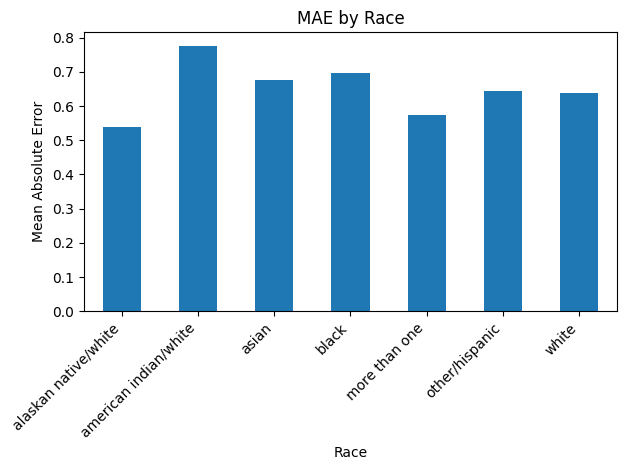

In [41]:
#Plot mae by race:
import matplotlib.pyplot as plt
mae_by_race.plot(kind='bar')
plt.title('MAE by Race')
plt.xlabel('Race')
plt.ylabel('Mean Absolute Error')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [45]:
#Seeing if differences in MAE across races are statistically significant using ANOVA:
results_df['abs_error'] = np.abs(results_df['y_true'] - results_df['y_pred'])

from scipy.stats import f_oneway

# Get errors per race group
groups = [
    group['abs_error'].values
    for name, group in results_df.groupby('race')
]

f_stat, p_value = f_oneway(*groups)

print(f"ANOVA F-statistic: {f_stat:.4f}, p-value: {p_value:.4f}")

from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(
    endog=results_df['abs_error'],
    groups=results_df['race'],
    alpha=0.05
)

print(tukey)

ANOVA F-statistic: 3.1051, p-value: 0.0049
               Multiple Comparison of Means - Tukey HSD, FWER=0.05                
        group1                group2        meandiff p-adj   lower   upper  reject
----------------------------------------------------------------------------------
 alaskan native/white american indian/white   0.2388 0.3028 -0.0833  0.5608  False
 alaskan native/white                 asian   0.1367 0.5318 -0.0844  0.3578  False
 alaskan native/white                 black   0.1575 0.4696 -0.0849  0.3998  False
 alaskan native/white         more than one   0.0372 0.9992 -0.1951  0.2696  False
 alaskan native/white        other/hispanic    0.107 0.8423 -0.1318  0.3458  False
 alaskan native/white                 white   0.0995 0.8322 -0.1192  0.3182  False
american indian/white                 asian   -0.102 0.8748  -0.343   0.139  False
american indian/white                 black  -0.0813 0.9695  -0.342  0.1793  False
american indian/white         more than one 

In [36]:
#Gender fairness evaluation:
mae_by_gender = results_df.groupby('gender').apply(
    lambda df: mean_absolute_error(df['y_true'], df['y_pred'])
)

mae_by_gender.index = mae_by_gender.index.map({0: 'Female', 1: 'Male'})
print(mae_by_gender)

gender
Female    0.646732
Male      0.638844
dtype: float64


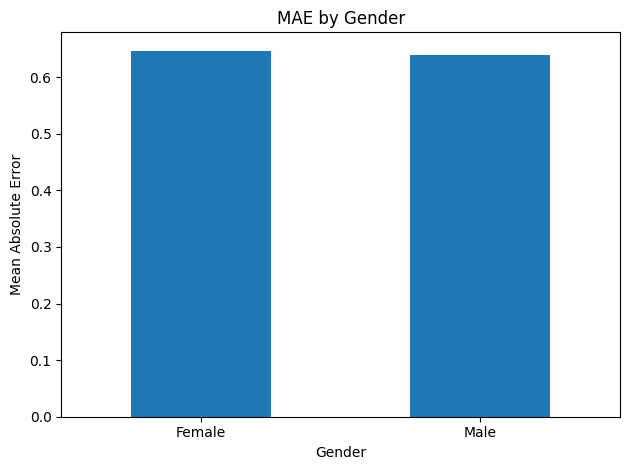

In [ ]:
#Plot mae by gender:
mae_by_gender.plot(kind='bar')
plt.title('MAE by Gender')
plt.xlabel('Gender')
plt.ylabel('Mean Absolute Error')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()